In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle
import matplotlib.colors as mcolors
from PIL import Image
import io

# Color data: (n_air, n_water, wavelength_nm)
# n_air ≈ 1.0003 for all visible; n_water varies with wavelength (dispersion)
COLOR_DATA = {
    "red":    {"n_air": 1.0003, "n_water": 1.3318, "wavelength": 700, "hex": "#FF0000"},
    "orange": {"n_air": 1.0003, "n_water": 1.3330, "wavelength": 620, "hex": "#FF7F00"},
    "yellow": {"n_air": 1.0003, "n_water": 1.3341, "wavelength": 580, "hex": "#FFFF00"},
    "green":  {"n_air": 1.0003, "n_water": 1.3360, "wavelength": 530, "hex": "#00CC00"},
    "cyan":   {"n_air": 1.0003, "n_water": 1.3378, "wavelength": 490, "hex": "#00FFFF"},
    "blue":   {"n_air": 1.0003, "n_water": 1.3404, "wavelength": 450, "hex": "#0000FF"},
    "violet": {"n_air": 1.0003, "n_water": 1.3435, "wavelength": 400, "hex": "#8B00FF"},
}

print("Color data loaded:")
for c, d in COLOR_DATA.items():
    print(f"  {c:8s}: n_water={d['n_water']}, λ={d['wavelength']}nm")


Color data loaded:
  red     : n_water=1.3318, λ=700nm
  orange  : n_water=1.333, λ=620nm
  yellow  : n_water=1.3341, λ=580nm
  green   : n_water=1.336, λ=530nm
  cyan    : n_water=1.3378, λ=490nm
  blue    : n_water=1.3404, λ=450nm
  violet  : n_water=1.3435, λ=400nm


In [10]:
def normalize(v):
    return v / np.linalg.norm(v)

def circle_intersect(origin, direction, center=np.array([0.0, 0.0]), radius=1.0):
    """
    Find intersection(s) of ray (origin + t*direction) with circle.
    Returns sorted list of (t, point, normal_outward) for t > 1e-9.
    """
    oc = origin - center
    d = direction
    a = np.dot(d, d)
    b = 2 * np.dot(oc, d)
    c = np.dot(oc, oc) - radius**2
    disc = b**2 - 4*a*c
    if disc < 0:
        return []
    sq = np.sqrt(disc)
    hits = []
    for t in [(-b - sq) / (2*a), (-b + sq) / (2*a)]:
        if t > 1e-9:
            pt = origin + t * d
            normal = normalize(pt - center)
            hits.append((t, pt, normal))
    hits.sort(key=lambda x: x[0])
    return hits

def snell_refract(incident, normal, n1, n2):
    """
    Refract incident direction through surface with given normal (pointing away from n2 medium).
    Returns refracted direction or None for total internal reflection.
    """
    i = normalize(incident)
    n = normalize(normal)
    cos_i = -np.dot(i, n)
    if cos_i < 0:
        n = -n
        cos_i = -np.dot(i, n)
    ratio = n1 / n2
    sin2_t = ratio**2 * (1 - cos_i**2)
    if sin2_t > 1.0:
        return None  # total internal reflection
    cos_t = np.sqrt(1 - sin2_t)
    return ratio * i + (ratio * cos_i - cos_t) * n

def reflect(incident, normal):
    i = normalize(incident)
    n = normalize(normal)
    return i - 2 * np.dot(i, n) * n

def trace_raindrop(h, color):
    """
    Trace a horizontal ray at height h through the unit-circle raindrop.
    Returns list of (start, end) segment tuples and the exit direction.
    """
    data = COLOR_DATA[color]
    n1 = data["n_air"]
    n2 = data["n_water"]

    # --- Segment 1: ray from left approaching the drop ---
    origin = np.array([-3.0, h])
    direction = np.array([1.0, 0.0])

    hits = circle_intersect(origin, direction)
    if len(hits) < 2:
        return None  # ray misses drop

    t_entry, pt_entry, normal_entry = hits[0]
    segments = [(origin, pt_entry)]

    # --- Refraction at entry ---
    # normal_entry points outward; n1 is outside (air), n2 inside (water)
    dir_refracted = snell_refract(direction, -normal_entry, n1, n2)
    if dir_refracted is None:
        return None

    # --- Segment 2: inside drop to back wall ---
    hits2 = circle_intersect(pt_entry, dir_refracted)
    if not hits2:
        return None
    t_back, pt_back, normal_back = hits2[0]
    segments.append((pt_entry, pt_back))

    # --- Internal reflection at back wall ---
    # normal_back points outward; reflect keeps ray inside
    dir_reflected = reflect(dir_refracted, normal_back)

    # --- Segment 3: inside drop to exit point ---
    hits3 = circle_intersect(pt_back, dir_reflected)
    if not hits3:
        return None
    t_exit, pt_exit, normal_exit = hits3[0]
    segments.append((pt_back, pt_exit))

    # --- Refraction at exit (water -> air) ---
    dir_exit = snell_refract(dir_reflected, normal_exit, n2, n1)
    if dir_exit is None:
        # TIR - extend ray inside briefly
        segments.append((pt_exit, pt_exit + dir_reflected * 0.5))
        return segments, dir_reflected

    # --- Segment 4: exiting ray ---
    segments.append((pt_exit, pt_exit + dir_exit * 1.5))
    return segments, dir_exit

# Quick test
result = trace_raindrop(0.5, "red")
print("Segments for h=0.5, red:")
for i, seg in enumerate(result[0]):
    print(f"  {i}: {seg[0]} -> {seg[1]}")


Segments for h=0.5, red:
  0: [-3.   0.5] -> [-0.8660254  0.5      ]
  1: [-0.8660254  0.5      ] -> [0.96980427 0.24388458]
  2: [0.96980427 0.24388458] -> [-0.52648326 -0.85018549]
  3: [-0.52648326 -0.85018549] -> [-1.84804421 -1.5597464 ]


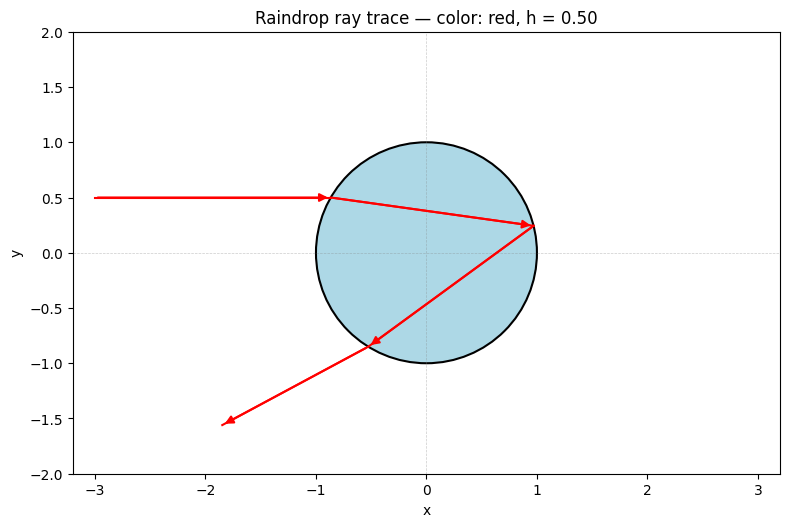

In [35]:
def draw_raindrop_ray(heights, color, ax=None, show_drop=True, figsize=(8, 8), show_exit_angle=False, show_title=True):
    """
    Draw the raindrop and ray path(s) for one or more heights.

    Parameters
    ----------
    heights : float or list of float
        Impact parameter(s) h in (0, 1].
    color : str
        Key from COLOR_DATA.
    ax : matplotlib Axes, optional
        If None a new figure is created.
    show_drop : bool
        Whether to draw the raindrop circle.
    figsize : tuple
        Figure size (used only when ax is None).
    show_exit_angle : bool
        If True, annotate the exit angle (degrees from backward horizontal)
        near the tip of each exit ray.

    Returns
    -------
    fig : matplotlib Figure
    """
    if np.isscalar(heights):
        heights = [heights]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        standalone = True
    else:
        fig = ax.get_figure()
        standalone = False

    if show_drop:
        circle = Circle((0, 0), 1.0, facecolor='lightblue', edgecolor='black', linewidth=1.5, zorder=1)
        ax.add_patch(circle)

    ray_color = COLOR_DATA[color]["hex"]

    for h in heights:
        result = trace_raindrop(h, color)
        if result is None:
            continue

        segments, exit_dir = result

        for seg_idx, seg in enumerate(segments):
            start, end = seg
            ax.annotate("", xy=end, xytext=start,
                        arrowprops=dict(arrowstyle="-|>", color=ray_color, lw=1.5,
                                       mutation_scale=12),
                        zorder=3)
            ax.plot([start[0], end[0]], [start[1], end[1]], color=ray_color, lw=1.5, zorder=3)

        if show_exit_angle:
            # Angle of exit ray measured from the backward horizontal (negative x-axis).
            # This is the "rainbow angle": 0° = straight back, positive = deflected away.
            exit_angle_deg = np.degrees(np.arctan2(-exit_dir[1], -exit_dir[0]))
            tip = segments[-1][1]  # end of the exit segment
            offset = exit_dir * 0.18  # nudge label along exit direction
            label_pos = tip + offset
            ax.text(label_pos[0], label_pos[1],
                    f"{exit_angle_deg:.1f}°",
                    fontsize=7.5, color=ray_color,
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=ray_color, alpha=0.8, lw=0.7),
                    zorder=5)

    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-2.0, 2.0)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5, ls='--', alpha=0.4)
    ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.4)

    label = f"h = {heights[0]:.2f}" if len(heights) == 1 else f"h = {heights[0]:.2f} … {heights[-1]:.2f}"
    if show_title:
        ax.set_title(f"Raindrop ray trace — color: {color}, {label}", fontsize=12)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if standalone:
        plt.tight_layout()
        plt.show()

    return fig

# Demo: single ray
draw_raindrop_ray(0.5, "red");


In [12]:
def make_gif(frames_spec, output_path="raindrop_animation.gif", figsize=(8, 8), duration_ms=400):
    """
    frames_spec: list of (h, color) tuples.
    Saves an animated GIF to output_path.
    """
    pil_frames = []
    for h, color in frames_spec:
        fig, ax = plt.subplots(figsize=figsize)
        # Draw drop
        circle = Circle((0, 0), 1.0, facecolor='lightblue', edgecolor='black', linewidth=1.5, zorder=1)
        ax.add_patch(circle)

        result = trace_raindrop(h, color)
        if result is not None:
            segments, _ = result
            ray_color = COLOR_DATA[color]["hex"]
            for seg in segments:
                start, end = seg
                ax.annotate("", xy=end, xytext=start,
                            arrowprops=dict(arrowstyle="-|>", color=ray_color, lw=1.5,
                                           mutation_scale=12),
                            zorder=3)
                ax.plot([start[0], end[0]], [start[1], end[1]], color=ray_color, lw=1.5, zorder=3)

        ax.set_xlim(-3.2, 3.2)
        ax.set_ylim(-2.0, 2.0)
        ax.set_aspect('equal')
        ax.axhline(0, color='gray', lw=0.5, ls='--', alpha=0.4)
        ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.4)
        ax.set_title(f"color: {color},  h = {h:.2f}", fontsize=12)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        plt.tight_layout()

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100)
        plt.close(fig)
        buf.seek(0)
        pil_frames.append(Image.open(buf).copy())

    pil_frames[0].save(
        output_path,
        save_all=True,
        append_images=pil_frames[1:],
        loop=0,
        duration=duration_ms,
    )
    print(f"Saved GIF with {len(pil_frames)} frames to: {output_path}")


# --- Build a nice animation: sweep h for each color ---
frames = []
heights = np.linspace(0.1, 0.95, 8)
colors_order = ["red", "orange", "yellow", "green", "cyan", "blue", "violet"]

for color in colors_order:
    for h in heights:
        frames.append((round(float(h), 3), color))

make_gif(frames, output_path="raindrop_animation.gif", duration_ms=150)


Saved GIF with 56 frames to: raindrop_animation.gif


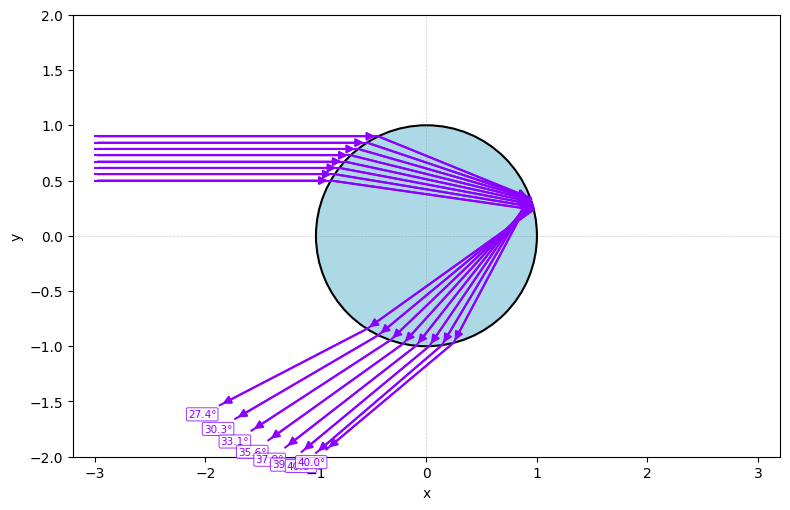

In [39]:
# Multiple rays at once, with exit angle labels
heights = np.linspace(0.5, 0.9, 8)
draw_raindrop_ray(heights, "violet", show_exit_angle=True, show_title=False);


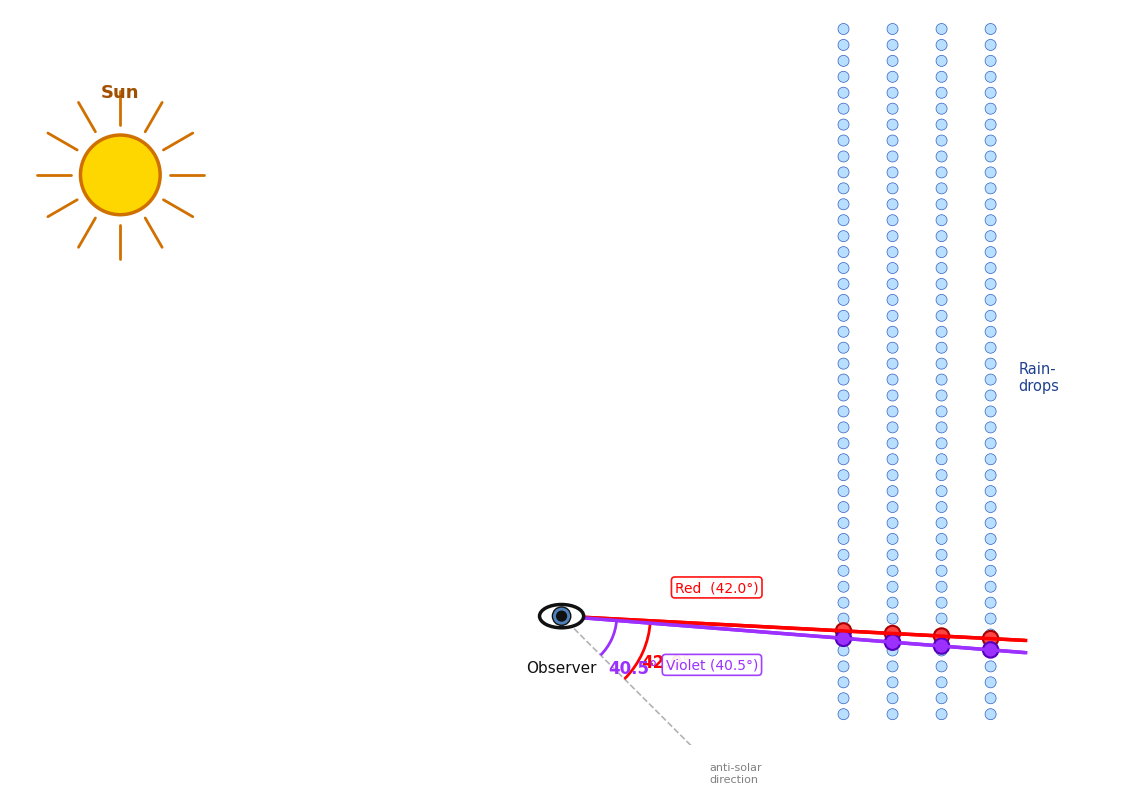

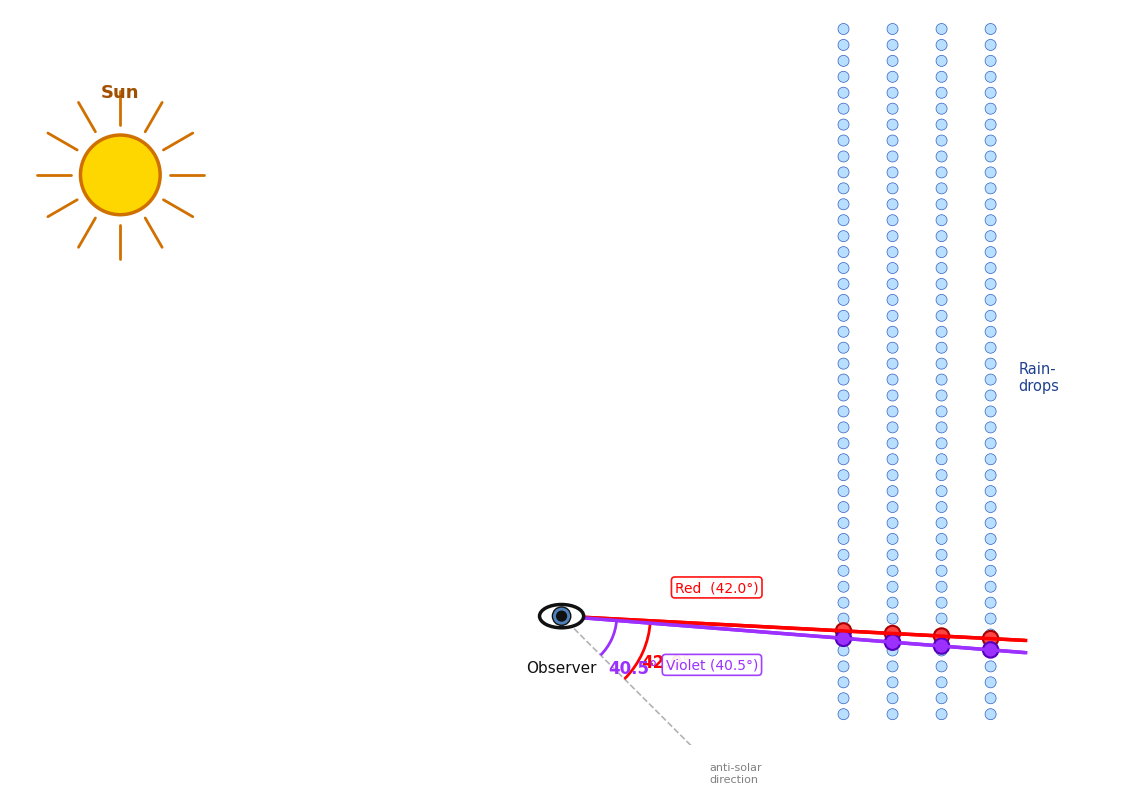

In [21]:

def draw_rainbow_overview(
    red_angle_deg=42.0,
    violet_angle_deg=40.5,
    figsize=(14, 8),
):
    """
    High-level schematic of primary rainbow formation.

    Multiple columns of small raindrops.  The ray from the observer at each
    rainbow angle threads through one highlighted drop per column.
    Arrow on each colour ray points *toward* the observer.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-9, 9)
    ax.set_ylim(-5.5, 6.5)
    ax.set_aspect('equal')
    ax.set_facecolor('#EEF5FB')
    ax.axis('off')

    EYE    = np.array([0.0, -3.4])
    SUN    = np.array([-7.2, 3.8])
    SUN_R  = 0.65

    SUN_ANGLE_DEG = -45
    sun_dir = np.array([np.cos(np.radians(SUN_ANGLE_DEG)), np.sin(np.radians(SUN_ANGLE_DEG))])
    perp    = np.array([-sun_dir[1], sun_dir[0]])

    WALL_X_COLS  = [4.6, 5.4, 6.2, 7.0]   # four columns
    DROP_R       = 0.09
    DROP_SPACING = 0.26
    HL_R         = DROP_R * 1.4            # highlighted drop radius

    # ── helpers ───────────────────────────────────────────────────────────────
    def ray_dir(rainbow_angle_deg):
        actual = SUN_ANGLE_DEG + rainbow_angle_deg
        return np.array([np.cos(np.radians(actual)), np.sin(np.radians(actual))])

    def ray_y_at(x_c, rainbow_angle_deg):
        return EYE[1] + (x_c - EYE[0]) * np.tan(np.radians(SUN_ANGLE_DEG + rainbow_angle_deg))

    def ray_far(rainbow_angle_deg, far_x=None):
        if far_x is None:
            far_x = max(WALL_X_COLS) + 0.6
        d = ray_dir(rainbow_angle_deg)
        return EYE + (far_x - EYE[0]) / d[0] * d

    # Exact highlighted positions (one per column, per colour)
    red_hls    = [(x_c, ray_y_at(x_c, red_angle_deg))    for x_c in WALL_X_COLS]
    violet_hls = [(x_c, ray_y_at(x_c, violet_angle_deg)) for x_c in WALL_X_COLS]

    # ── Sun ──────────────────────────────────────────────────────────────────
    ax.add_patch(Circle(SUN, SUN_R, color='#FFD700', ec='#D07000', lw=2.5, zorder=6))
    for deg in range(0, 360, 30):
        v = np.array([np.cos(np.radians(deg)), np.sin(np.radians(deg))])
        p0, p1 = SUN + SUN_R * 1.25 * v, SUN + SUN_R * 2.1 * v
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], '#D07000', lw=2,
                solid_capstyle='round', zorder=6)
    ax.text(SUN[0], SUN[1] + SUN_R + 0.55, 'Sun',
            ha='center', va='bottom', fontsize=13, fontweight='bold',
            color='#A05000', zorder=7)

    # ── Parallel sun rays (end at last column) ────────────────────────────────
    far_x_sun = max(WALL_X_COLS) + 0.3
    for off in np.linspace(-3.2, 4.2, 10):
        start = np.array([-8.0, 1.5]) + off * perp
        t     = (far_x_sun - start[0]) / sun_dir[0]
        end   = start + t * sun_dir
        if not (-5.5 < start[1] < 6.5 and -5.5 < end[1] < 6.5):
            continue
        ax.plot([start[0], end[0]], [start[1], end[1]],
                color='#FFD700', lw=1.5, alpha=0.75, zorder=2)
        ax.annotate("", xy=tuple(end), xytext=tuple(start),
                    arrowprops=dict(arrowstyle="-|>", color='#FFD700',
                                   lw=1.5, mutation_scale=9),
                    zorder=2)

    # ── Raindrop columns (drops on top of sun rays) ───────────────────────────
    for x_c in WALL_X_COLS:
        for y in np.arange(-5.0, 6.3, DROP_SPACING):
            ax.add_patch(Circle((x_c, y), DROP_R,
                                 facecolor='#B8DFFF', edgecolor='#3060C0',
                                 lw=0.5, zorder=3))
    ax.text(max(WALL_X_COLS) + 0.45, 0.5, 'Rain-\ndrops',
            ha='left', va='center', fontsize=10.5, color='#204090', zorder=7)

    # ── Coloured rays: far end → eye, arrow at eye ────────────────────────────
    # Drawn below highlighted drops (zorder=4) so highlights appear on top
    for angle_deg, col in [(red_angle_deg, 'red'), (violet_angle_deg, '#9B30FF')]:
        far_pt = ray_far(angle_deg)
        ax.plot([far_pt[0], EYE[0]], [far_pt[1], EYE[1]],
                color=col, lw=2.5, zorder=4, solid_capstyle='butt')
        ax.annotate("", xy=tuple(EYE), xytext=tuple(far_pt),
                    arrowprops=dict(arrowstyle="-|>", color=col,
                                   lw=2.5, mutation_scale=16),
                    zorder=7)

    # ── Highlighted drops (drawn over ray lines) ──────────────────────────────
    for x_c, y_r in red_hls:
        ax.add_patch(Circle((x_c, y_r), HL_R,
                             facecolor='#FF4444', edgecolor='#AA0000',
                             lw=1.5, zorder=5))
    for x_c, y_v in violet_hls:
        ax.add_patch(Circle((x_c, y_v), HL_R,
                             facecolor='#9B30FF', edgecolor='#5500BB',
                             lw=1.5, zorder=5))

    # ── Angle reference & arcs ────────────────────────────────────────────────
    ref_end = EYE + sun_dir * 3.2
    ax.plot([EYE[0], ref_end[0]], [EYE[1], ref_end[1]],
            color='gray', lw=1.2, ls='--', alpha=0.6, zorder=4)
    ax.text(ref_end[0] + 0.15, ref_end[1] - 0.30, 'anti-solar\ndirection',
            ha='left', va='center', fontsize=8, color='gray', zorder=5)

    r_arc = 1.45
    ax.add_patch(patches.Arc(EYE, 2*r_arc, 2*r_arc, angle=0,
                              theta1=SUN_ANGLE_DEG,
                              theta2=SUN_ANGLE_DEG + red_angle_deg,
                              color='red', lw=2, zorder=5))
    mid_r = np.radians(SUN_ANGLE_DEG + red_angle_deg / 2)
    ax.text(EYE[0] + (r_arc + 0.42) * np.cos(mid_r),
            EYE[1] + (r_arc + 0.42) * np.sin(mid_r),
            f'{red_angle_deg:.1f}°', color='red',
            fontsize=12, fontweight='bold', ha='center', va='center', zorder=6)

    v_arc = 0.90
    ax.add_patch(patches.Arc(EYE, 2*v_arc, 2*v_arc, angle=0,
                              theta1=SUN_ANGLE_DEG,
                              theta2=SUN_ANGLE_DEG + violet_angle_deg,
                              color='#9B30FF', lw=2, zorder=5))
    mid_v = np.radians(SUN_ANGLE_DEG + violet_angle_deg / 2)
    ax.text(EYE[0] + (v_arc + 0.38) * np.cos(mid_v),
            EYE[1] + (v_arc + 0.38) * np.sin(mid_v) - 0.32,
            f'{violet_angle_deg:.1f}°', color='#9B30FF',
            fontsize=12, fontweight='bold', ha='center', va='center', zorder=6)

    # ── Observer ──────────────────────────────────────────────────────────────
    ax.add_patch(patches.Ellipse(EYE, 0.72, 0.38,
                                  color='white', ec='#111', lw=2.5, zorder=8))
    ax.add_patch(Circle(EYE, 0.15, color='#5080BB', ec='#111', lw=1, zorder=9))
    ax.add_patch(Circle(EYE, 0.08, color='#111', zorder=10))
    ax.text(EYE[0], EYE[1] - 0.72, 'Observer',
            ha='center', va='top', fontsize=11, color='#111', zorder=10)

    # ── Ray labels (offset perpendicular to each ray) ─────────────────────────
    for angle_deg, col, label, sign in [
        (red_angle_deg,    'red',     f'Red  ({red_angle_deg:.1f}°)',      +1),
        (violet_angle_deg, '#9B30FF', f'Violet ({violet_angle_deg:.1f}°)', -1),
    ]:
        d        = ray_dir(angle_deg)
        perp_ray = np.array([-d[1], d[0]])       # 90° CCW = "above" the ray
        t        = (2.5 - EYE[0]) / d[0]
        pt       = EYE + t * d
        label_pt = pt + sign * 0.60 * perp_ray
        ax.text(label_pt[0], label_pt[1], label,
                color=col, fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.25', fc='white',
                          ec=col, alpha=0.92, lw=1.2), zorder=8)

    plt.tight_layout()
    return fig


draw_rainbow_overview()
